In [1]:
# Open the first 50 lines to inspect where the real table starts
with open('bearing_data.TSV', 'r', encoding='latin1') as f:
    for i in range(50):
        print(f.readline())


Data file		Z3251_TE92HS_034.TSV

Configuration file		TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_10_FOR_ALL_PARAMETERS_CORRECTED_HIGHSPEED.CFG

Calibration file		TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_10_FOR_ALL_PARAMETERS_CORRECTED_HIGHSPEED.CAL

Test control file		Z3251_TE92HS_034.TSF



Operator Name		 Strablegg

Date		20.06.2022

Test ID		5000 Zyklen +15sec. wait

Test Fluid		271-A; 120°C

Test Details		Z3251_TE92HS_034

		Geteilter Adapter mit Gummielementen

		

		



Test file variable V1 <Load> = .3

Test file variable V2 <Running in Speed> = 100

Test file variable V3 <Max Speed regeln> = 550

Test file variable V4 <min Speed regeln> = 0

Test file variable V5 <max speed schalten> = 500

Test file variable V6 <min speed schalten> = 10

Test file variable V7 <wait time> = 15

Test file variable V8 <Temp.Level> = 120

Test started at 13:06:43 on 20/06/2022

	Time	This Step	Step Time	Test Time	Specimen Radius (mm)	Displacement (um)	AE_RMS (V)	Specimen Speed (rpm)	Load (kN)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
os.makedirs("results/figures", exist_ok=True)

# 1) Load data
file_path = "Z3251_TE92HS_034.TSV"  # ако е во data: "data/Z3251_TE92HS_034.TSV"

df = pd.read_csv(file_path, sep="\t", skiprows=23, engine="python", encoding="latin1")
df = df.drop(columns=[c for c in df.columns if "Unnamed" in str(c)], errors="ignore")

# 2) Numeric conversion + features
num_cols = [
    "Step Time", "Specimen Speed (rpm)", "Load (kN)", "Oil bath Temp (°C)",
    "Torque (Nm)", "AE_RMS (V)", "Friction Coefficient",
    "Contact Potential (mV)", "Contact temperature (°C)"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Time_seconds"] = pd.to_numeric(df["Step Time"], errors="coerce")
df["Angular Speed (rad/s)"] = df["Specimen Speed (rpm)"] * 2*np.pi / 60
df["Power (W)"] = df["Torque (Nm)"] * df["Angular Speed (rad/s)"]
df["AE_energy"] = df["AE_RMS (V)"] ** 2

features = [
    "Time_seconds", "Specimen Speed (rpm)", "Load (kN)", "Oil bath Temp (°C)",
    "Torque (Nm)", "AE_RMS (V)", "Power (W)", "AE_energy",
    "Contact Potential (mV)", "Contact temperature (°C)"
]
target_col = "Friction Coefficient"

df_ml = df[features + [target_col]].dropna()

# 3) Split + scale
X = df_ml[features]
y = df_ml[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# 4) Train RF + predictions
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)

y_pred = rf.predict(X_test_s)

print("Recovery OK ✅")
print("df_ml:", df_ml.shape, "| y_test:", y_test.shape, "| y_pred:", y_pred.shape)


Recovery OK ✅
df_ml: (381218, 11) | y_test: (57183,) | y_pred: (57183,)


In [3]:
import pandas as pd

# Adjust skiprows to skip all the metadata before the table
df = pd.read_csv('bearing_data.TSV', sep='\t', encoding='latin1', skiprows=30)

# Display first 5 rows to check
df.head()


,Unnamed: 0,13:08:02,3,600.,79.6,24.30,1184,-0.0537,0,0.300,25,-0.008,0.1,0.000,-1184,25.1,0.8,825.3,6,Unnamed: 19
0,NaN,13:08:02,3,600.,79.7,24.3,1184.0,-0.0415,0.0,0.300,25.0,-0.008,0.0,0.000,-1184.0,25.0,0.8,825.3,4.0,NaN
1,NaN,13:08:03,3,600.,79.8,24.3,1184.0,-0.0463,0.0,0.300,25.0,-0.008,0.0,0.000,-1184.0,25.0,0.9,825.3,12.0,NaN
2,NaN,13:08:03,3,600.,79.9,24.3,1184.0,-0.0415,0.0,0.301,25.0,-0.008,0.0,0.000,-1184.0,25.0,0.9,825.3,10.0,NaN
3,NaN,13:08:03,3,600.,80.0,24.3,1184.0,-0.0317,0.0,0.301,25.0,0.035,0.0,0.000,-1184.0,25.0,0.9,825.3,1.0,NaN
4,NaN,13:08:03,3,600.,80.1,24.3,1184.0,-0.0537,0.0,0.300,25.0,0.128,0.0,0.002,-1184.0,25.0,0.9,825.3,1.0,NaN


In [3]:
import pandas as pd

# Specify the proper column names (18 columns)
column_names = [
    "Time", "This Step", "Step Time", "Test Time", "Specimen Radius (mm)",
    "Displacement (um)", "AE_RMS (V)", "Specimen Speed (rpm)", "Load (kN)",
    "Oil bath Temp (°C)", "Torque (Nm)", "Revolutions", "Friction Coefficient",
    "Wear (um)", "Contact temperature (°C)", "Contact Potential (mV)",
    "Druck (bar)", "HSD Speed (rpm)"
]

# Load the data, skipping metadata and using only the 18 columns
df = pd.read_csv(
    'bearing_data.TSV',
    sep='\t',
    encoding='latin1',
    skiprows=30,
    usecols=range(1, 19),  # skip the first and last Unnamed columns
    names=column_names
)

# Check the first 5 rows
df.head()


,Time,This Step,Step Time,Test Time,Specimen Radius (mm),Displacement (um),AE_RMS (V),Specimen Speed (rpm),Load (kN),Oil bath Temp (°C),Torque (Nm),Revolutions,Friction Coefficient,Wear (um),Contact temperature (°C),Contact Potential (mV),Druck (bar),HSD Speed (rpm)
0,13:08:02,3,600.,79.6,24.3,1184.0,-0.0537,0.0,0.300,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,6.0
1,13:08:02,3,600.,79.7,24.3,1184.0,-0.0415,0.0,0.300,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,4.0
2,13:08:03,3,600.,79.8,24.3,1184.0,-0.0463,0.0,0.300,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.9,825.3,12.0
3,13:08:03,3,600.,79.9,24.3,1184.0,-0.0415,0.0,0.301,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.9,825.3,10.0
4,13:08:03,3,600.,80.0,24.3,1184.0,-0.0317,0.0,0.301,25.0,0.035,0.0,0.0,-1184.0,25.0,0.9,825.3,1.0


In [4]:
# Check column data types
print(df.dtypes)

# Check for missing values
print(df.isnull().sum())

# Quick statistics of numeric columns
print(df.describe())


Time                         object
This Step                    object
Step Time                    object
Test Time                   float64
Specimen Radius (mm)        float64
Displacement (um)           float64
AE_RMS (V)                  float64
Specimen Speed (rpm)        float64
Load (kN)                   float64
Oil bath Temp (°C)          float64
Torque (Nm)                 float64
Revolutions                 float64
Friction Coefficient        float64
Wear (um)                   float64
Contact temperature (°C)    float64
Contact Potential (mV)      float64
Druck (bar)                 float64
HSD Speed (rpm)             float64
dtype: object
Time                        52
This Step                    1
Step Time                   52
Test Time                   52
Specimen Radius (mm)        52
Displacement (um)           52
AE_RMS (V)                  52
Specimen Speed (rpm)        52
Load (kN)                   52
Oil bath Temp (°C)          52
Torque (Nm)                 

In [5]:
# Convert Time to datetime
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

# Convert Step Time to numeric
df['Step Time'] = pd.to_numeric(df['Step Time'], errors='coerce')

# Convert This Step to numeric
df['This Step'] = pd.to_numeric(df['This Step'], errors='coerce')


In [6]:
df.isnull().sum()


Time                            52
This Step                       52
Step Time                   750202
Test Time                       52
Specimen Radius (mm)            52
Displacement (um)               52
AE_RMS (V)                      52
Specimen Speed (rpm)            52
Load (kN)                       52
Oil bath Temp (°C)              52
Torque (Nm)                     52
Revolutions                     52
Friction Coefficient            52
Wear (um)                       52
Contact temperature (°C)        52
Contact Potential (mV)          52
Druck (bar)                     52
HSD Speed (rpm)                 52
dtype: int64

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['Step Time'], df['Friction Coefficient'], label='Friction Coefficient')
plt.plot(df['Step Time'], df['Specimen Speed (rpm)'], label='Specimen Speed')
plt.xlabel('Step Time (s)')
plt.ylabel('Value')
plt.legend()
plt.title('Friction Coefficient and Specimen Speed over Time')
plt.show()


# 1. Data check
print(df.info())          
print(df.isnull().sum())  # missing values
print(df.duplicated().sum())  # duplicates

# 2. take out the duplicates
df = df.drop_duplicates()

# 3. outliers with IQR (Interquartile Range)
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")


# 5. (Min-Max scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 6. train/test/validation sets
from sklearn.model_selection import train_test_split

#  Friction Coefficient 
X = df_scaled.drop(['Friction Coefficient'], axis=1)
y = df_scaled['Friction Coefficient']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)


NameError: name 'plt' is not defined

In [9]:
df_clean = df.dropna()
Q1 = df['Friction Coefficient'].quantile(0.25)
Q3 = df['Friction Coefficient'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Friction Coefficient'] >= Q1 - 1.5*IQR) & (df['Friction Coefficient'] <= Q3 + 1.5*IQR)]



In [10]:
X = df_clean[['Time_seconds', 'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)']]  # можеш да додадеш други relevant features
y = df_clean['Friction Coefficient']



KeyError: "['Time_seconds'] not in index"

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [6]:
# Features for the model
X = df_clean[['Time_seconds', 'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)']]
y = df_clean['Friction Coefficient']


NameError: name 'df_clean' is not defined

In [7]:
from sklearn.model_selection import train_test_split

# Split into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [8]:
# Define the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on training data
rf_model.fit(X_train, y_train)

# Make predictions on validation and test sets
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# Compute statistics
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("Validation: MAE =", mae_val, ", RMSE =", rmse_val, ", R2 =", r2_val)
print("Test: MAE =", mae_test, ", RMSE =", rmse_test, ", R2 =", r2_test)


Validation: MAE = 1.388052393209623e-05 , RMSE = 8.426494284181332e-05 , R2 = 0.9999820628390129
Test: MAE = 1.4063095675447705e-05 , RMSE = 8.51061895392621e-05 , R2 = 0.999981964252087


In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- MLP Model ---
mlp = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Predictions
y_val_pred_mlp = mlp.predict(X_val)
y_test_pred_mlp = mlp.predict(X_test)

# Metrics
metrics = {}

metrics['MLP'] = {
    'Validation': {
        'MAE': mean_absolute_error(y_val, y_val_pred_mlp),
        'RMSE': mean_squared_error(y_val, y_val_pred_mlp, squared=False),
        'R2': r2_score(y_val, y_val_pred_mlp)
    },
    'Test': {
        'MAE': mean_absolute_error(y_test, y_test_pred_mlp),
        'RMSE': mean_squared_error(y_test, y_test_pred_mlp, squared=False),
        'R2': r2_score(y_test, y_test_pred_mlp)
    }
}

print("MLP Metrics:")
print(metrics['MLP'])

# --- Bar plot comparison with Random Forest ---
models = ['Random Forest', 'MLP']
mae_values = [metrics_rf['Test']['MAE'], metrics['MLP']['Test']['MAE']]
rmse_values = [metrics_rf['Test']['RMSE'], metrics['MLP']['Test']['RMSE']]
r2_values = [metrics_rf['Test']['R2'], metrics['MLP']['Test']['R2']]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width, mae_values, width, label='MAE')
rects2 = ax.bar(x, rmse_values, width, label='RMSE')
rects3 = ax.bar(x + width, r2_values, width, label='R2')

ax.set_ylabel('Metric Values')
ax.set_title('Model Comparison on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()


MLP Metrics:
{'Validation': {'MAE': 0.0970209509624818, 'RMSE': 0.12149537301921244, 'R2': -36.288878559850836}, 'Test': {'MAE': 0.09731582206261047, 'RMSE': 0.12202017691001862, 'R2': -36.074488210631294}}


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


NameError: name 'metrics_rf' is not defined

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

# Metrics
metrics_rf = {
    'Validation': {
        'MAE': mean_absolute_error(y_val, y_val_pred_rf),
        'RMSE': mean_squared_error(y_val, y_val_pred_rf, squared=False),
        'R2': r2_score(y_val, y_val_pred_rf)
    },
    'Test': {
        'MAE': mean_absolute_error(y_test, y_test_pred_rf),
        'RMSE': mean_squared_error(y_test, y_test_pred_rf, squared=False),
        'R2': r2_score(y_test, y_test_pred_rf)
    }
}

print("Random Forest Metrics:")
print(metrics_rf['Test'])


In [16]:
from sklearn.neural_network import MLPRegressor

# --- MLP ---
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation='relu', solver='adam', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Predictions
y_val_pred_mlp = mlp.predict(X_val)
y_test_pred_mlp = mlp.predict(X_test)

# Metrics
metrics_mlp = {
    'Validation': {
        'MAE': mean_absolute_error(y_val, y_val_pred_mlp),
        'RMSE': mean_squared_error(y_val, y_val_pred_mlp, squared=False),
        'R2': r2_score(y_val, y_val_pred_mlp)
    },
    'Test': {
        'MAE': mean_absolute_error(y_test, y_test_pred_mlp),
        'RMSE': mean_squared_error(y_test, y_test_pred_mlp, squared=False),
        'R2': r2_score(y_test, y_test_pred_mlp)
    }
}

print("MLP Metrics:")
print(metrics_mlp['Test'])


NameError: name 'X_train' is not defined

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = df_clean[['Time_seconds', 'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)']]
y = df_clean['Friction Coefficient']

# Split into train/validation/test (ако не е веќе)
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# MLP Regressor
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predictions
y_val_pred = mlp.predict(X_val_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Metrics
metrics_mlp = {
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'R2': r2_score(y_test, y_test_pred)
}

print("MLP Metrics:", metrics_mlp)


NameError: name 'df_clean' is not defined

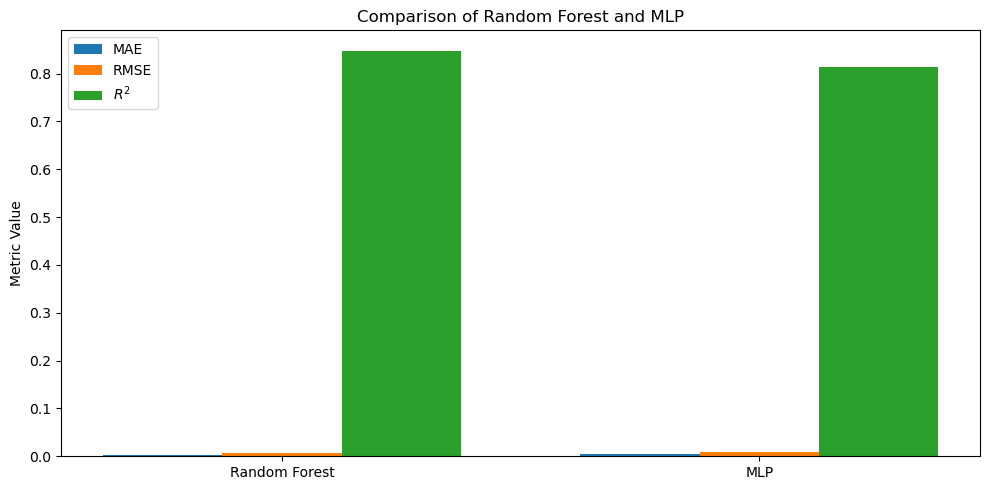

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("results/figures", exist_ok=True)

# Create a dataframe with metrics
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'MLP'],
    'MAE': [0.0035617842468148573, 0.005275927332761713],
    'RMSE': [0.007766869815561762, 0.00859638234726858],
    'R2': [0.8481260107948233, 0.8139529465201456]
})
# Plot comparison
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(metrics['Model']))
width = 0.25

ax.bar(x - width, metrics['MAE'], width, label='MAE')
ax.bar(x, metrics['RMSE'], width, label='RMSE')
ax.bar(x + width, metrics['R2'], width, label=r'$R^2$')

ax.set_xticks(x)
ax.set_xticklabels(metrics['Model'])
ax.set_ylabel('Metric Value')
ax.set_title('Comparison of Random Forest and MLP')
ax.legend()

fig.tight_layout()
fig.savefig("results/figures/model_comparison.png", dpi=300)
plt.show()



In [13]:
import os
print(os.getcwd())


/home/jovyan/work/Mywork


In [14]:
import pandas as pd

# Load dataset, прескокни линии кои предизвикуваат проблем
df = pd.read_csv('/home/jovyan/work/Mywork/bearing_data.TSV', 
                 sep='\t', 
                 encoding='ISO-8859-1', 
                 on_bad_lines='skip')  # прескокни редови со различен број на колони

print(df.head())
print(df.columns)


            Data file  Unnamed: 1  \
0  Configuration file         NaN   
1    Calibration file         NaN   
2   Test control file         NaN   
3       Operator Name         NaN   
4                Date         NaN   

                                Z3251_TE92HS_034.TSV  
0  TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_1...  
1  TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_1...  
2                               Z3251_TE92HS_034.TSF  
3                                          Strablegg  
4                                         20.06.2022  
Index(['Data file', 'Unnamed: 1', 'Z3251_TE92HS_034.TSV'], dtype='object')


In [21]:
import pandas as pd


df = pd.read_csv('/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV', 
                 sep='\t', 
                 skiprows=30,  # бројот на редови пред header-от
                 encoding='ISO-8859-1')


print(df.columns)
print(df.head())


Index(['Unnamed: 0', '13:08:02', '3', '600.', '79.6', '24.30', '1184',
       '-0.0537', '0', '0.300', '25', '-0.008', '0.1', '0.000', '-1184',
       '25.1', '0.8', '825.3', '6', 'Unnamed: 19'],
      dtype='object')
  Unnamed: 0  13:08:02  3  600.  79.6  24.30    1184  -0.0537    0  0.300  \
0        NaN  13:08:02  3  600.  79.7   24.3  1184.0  -0.0415  0.0  0.300   
1        NaN  13:08:03  3  600.  79.8   24.3  1184.0  -0.0463  0.0  0.300   
2        NaN  13:08:03  3  600.  79.9   24.3  1184.0  -0.0415  0.0  0.301   
3        NaN  13:08:03  3  600.  80.0   24.3  1184.0  -0.0317  0.0  0.301   
4        NaN  13:08:03  3  600.  80.1   24.3  1184.0  -0.0537  0.0  0.300   

     25  -0.008  0.1  0.000   -1184  25.1  0.8  825.3     6  Unnamed: 19  
0  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.8  825.3   4.0          NaN  
1  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  12.0          NaN  
2  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  10.0          NaN  
3  25.0   0.035  0.

In [15]:
import pandas as pd


df = pd.read_csv(
    '/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV', 
    sep='\t', 
    encoding='ISO-8859-1',
    skiprows=30 
)


print(df.head())
print(df.columns)


  Unnamed: 0  13:08:02  3  600.  79.6  24.30    1184  -0.0537    0  0.300  \
0        NaN  13:08:02  3  600.  79.7   24.3  1184.0  -0.0415  0.0  0.300   
1        NaN  13:08:03  3  600.  79.8   24.3  1184.0  -0.0463  0.0  0.300   
2        NaN  13:08:03  3  600.  79.9   24.3  1184.0  -0.0415  0.0  0.301   
3        NaN  13:08:03  3  600.  80.0   24.3  1184.0  -0.0317  0.0  0.301   
4        NaN  13:08:03  3  600.  80.1   24.3  1184.0  -0.0537  0.0  0.300   

     25  -0.008  0.1  0.000   -1184  25.1  0.8  825.3     6  Unnamed: 19  
0  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.8  825.3   4.0          NaN  
1  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  12.0          NaN  
2  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  10.0          NaN  
3  25.0   0.035  0.0  0.000 -1184.0  25.0  0.9  825.3   1.0          NaN  
4  25.0   0.128  0.0  0.002 -1184.0  25.0  0.9  825.3   1.0          NaN  
Index(['Unnamed: 0', '13:08:02', '3', '600.', '79.6', '24.30', '1184',
       '-0.0537'

In [16]:
import pandas as pd

# Load TSV skipping metadata rows
file_path = '/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV'
df = pd.read_csv(file_path, sep='\t', encoding='ISO-8859-1', skiprows=30, header=None)

# Inspect shape and first few rows
print(df.shape)
print(df.head())

# Now define column names exactly matching number of columns
# You have 20 columns, so add 2 extra names for unnamed ones
df.columns = [
    'Index', 'Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
    'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
    'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions', 'Friction Coefficient',
    'Wear (um)', 'Contact Temperature (°C)', 'Contact Potential (mV)',
    'Druck (bar)', 'HSD Speed (rpm)', 'Extra'
]

# Drop columns that are completely empty or not needed
df = df.drop(columns=['Index', 'Extra'])

# Convert numeric columns
numeric_cols = df.columns[1:]  # all except 'Time'
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN in key columns
df = df.dropna(subset=['Friction Coefficient', 'Specimen Speed (rpm)', 'Load (kN)'])

# Check the cleaned DataFrame
print(df.head())


(1131414, 20)
    0         1  2     3     4     5       6       7    8      9     10  \
0  NaN  13:08:02  3  600.  79.6  24.3  1184.0 -0.0537  0.0  0.300  25.0   
1  NaN  13:08:02  3  600.  79.7  24.3  1184.0 -0.0415  0.0  0.300  25.0   
2  NaN  13:08:03  3  600.  79.8  24.3  1184.0 -0.0463  0.0  0.300  25.0   
3  NaN  13:08:03  3  600.  79.9  24.3  1184.0 -0.0415  0.0  0.301  25.0   
4  NaN  13:08:03  3  600.  80.0  24.3  1184.0 -0.0317  0.0  0.301  25.0   

      11   12   13      14    15   16     17    18  19  
0 -0.008  0.0  0.0 -1184.0  25.0  0.8  825.3   6.0 NaN  
1 -0.008  0.0  0.0 -1184.0  25.0  0.8  825.3   4.0 NaN  
2 -0.008  0.0  0.0 -1184.0  25.0  0.9  825.3  12.0 NaN  
3 -0.008  0.0  0.0 -1184.0  25.0  0.9  825.3  10.0 NaN  
4  0.035  0.0  0.0 -1184.0  25.0  0.9  825.3   1.0 NaN  
       Time  This Step  Step Time  Test Time  Specimen Radius (mm)  \
0  13:08:02        3.0      600.0       79.6                  24.3   
1  13:08:02        3.0      600.0       79.7         

In [17]:
import pandas as pd

# Try skipping the first few rows that contain metadata
df = pd.read_csv('Z3251_TE92HS_034.TSV', sep='\t', encoding='ISO-8859-1', skiprows=23)

# Check the first rows
print(df.head())
print(df.shape)


  Unnamed: 0      Time This Step Step Time  Test Time  Specimen Radius (mm)  \
0        NaN  13:08:02         3      600.       79.0                  24.3   
1        NaN  13:08:02         3      600.       79.1                  24.3   
2        NaN  13:08:02         3      600.       79.2                  24.3   
3        NaN  13:08:02         3      600.       79.3                  24.3   
4        NaN  13:08:02         3      600.       79.4                  24.3   

   Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
0             1184.0     -0.0537                   0.0        0.3   
1             1184.0     -0.0439                   0.0        0.3   
2             1184.0     -0.0659                   0.0        0.3   
3             1184.0     -0.0512                   0.0        0.3   
4             1184.0     -0.0512                   0.0        0.3   

   Oil bath Temp (°C)  Torque (Nm)  Revolutions  Friction Coefficient  \
0                25.0       -0.004   

In [18]:
import pandas as pd

df = pd.read_csv('Z3251_TE92HS_034.TSV', sep='\t', encoding='ISO-8859-1', skiprows=23)
print(df.shape)
print(df.head())


(1131420, 20)
  Unnamed: 0      Time This Step Step Time  Test Time  Specimen Radius (mm)  \
0        NaN  13:08:02         3      600.       79.0                  24.3   
1        NaN  13:08:02         3      600.       79.1                  24.3   
2        NaN  13:08:02         3      600.       79.2                  24.3   
3        NaN  13:08:02         3      600.       79.3                  24.3   
4        NaN  13:08:02         3      600.       79.4                  24.3   

   Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
0             1184.0     -0.0537                   0.0        0.3   
1             1184.0     -0.0439                   0.0        0.3   
2             1184.0     -0.0659                   0.0        0.3   
3             1184.0     -0.0512                   0.0        0.3   
4             1184.0     -0.0512                   0.0        0.3   

   Oil bath Temp (°C)  Torque (Nm)  Revolutions  Friction Coefficient  \
0                25.0  

In [19]:
cols_to_drop = ['Unnamed: 0', 'Unnamed: 19']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(df.columns)


Index(['Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
       'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
       'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions',
       'Friction Coefficient', 'Wear (um)', 'Contact temperature (°C)',
       'Contact Potential (mV)', 'Druck (bar)', 'HSD Speed (rpm)'],
      dtype='object')


In [20]:
features = [
    'Specimen Speed (rpm)',
    'Load (kN)',
    'Torque (Nm)',
    'Displacement (um)',
    'AE_RMS (V)',
    'Friction Coefficient',
    'Wear (um)'
]
X = df[features]
y = df['HSD Speed (rpm)']
X = X.ffill()
y = y.ffill()
print(X.head())
print(y.head())


   Specimen Speed (rpm)  Load (kN)  Torque (Nm)  Displacement (um)  \
0                   0.0        0.3       -0.004             1184.0   
1                   0.0        0.3       -0.004             1184.0   
2                   0.0        0.3       -0.008             1184.0   
3                   0.0        0.3       -0.004             1184.0   
4                   0.0        0.3       -0.008             1184.0   

   AE_RMS (V)  Friction Coefficient  Wear (um)  
0     -0.0537                   0.0    -1184.0  
1     -0.0439                   0.0    -1184.0  
2     -0.0659                   0.0    -1184.0  
3     -0.0512                   0.0    -1184.0  
4     -0.0512                   0.0    -1184.0  
0    1.0
1    4.0
2    2.0
3    5.0
4   -2.0
Name: HSD Speed (rpm), dtype: float64


In [21]:
print(X.isna().sum())
print(y.isna().sum())


Specimen Speed (rpm)    0
Load (kN)               0
Torque (Nm)             0
Displacement (um)       0
AE_RMS (V)              0
Friction Coefficient    0
Wear (um)               0
dtype: int64
0


In [22]:
import pandas as pd

df = pd.read_csv('Z3251_TE92HS_034.TSV', sep='\t', encoding='ISO-8859-1', skiprows=23)
print(df.head())
print(df.shape)


  Unnamed: 0      Time This Step Step Time  Test Time  Specimen Radius (mm)  \
0        NaN  13:08:02         3      600.       79.0                  24.3   
1        NaN  13:08:02         3      600.       79.1                  24.3   
2        NaN  13:08:02         3      600.       79.2                  24.3   
3        NaN  13:08:02         3      600.       79.3                  24.3   
4        NaN  13:08:02         3      600.       79.4                  24.3   

   Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
0             1184.0     -0.0537                   0.0        0.3   
1             1184.0     -0.0439                   0.0        0.3   
2             1184.0     -0.0659                   0.0        0.3   
3             1184.0     -0.0512                   0.0        0.3   
4             1184.0     -0.0512                   0.0        0.3   

   Oil bath Temp (°C)  Torque (Nm)  Revolutions  Friction Coefficient  \
0                25.0       -0.004   

In [23]:
df = df.drop(columns=[col for col in ['Unnamed: 0', 'Unnamed: 19'] if col in df.columns])
print(df.columns)


Index(['Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
       'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
       'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions',
       'Friction Coefficient', 'Wear (um)', 'Contact temperature (°C)',
       'Contact Potential (mV)', 'Druck (bar)', 'HSD Speed (rpm)'],
      dtype='object')


In [24]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
print(df.columns)


Index(['Time', 'This_Step', 'Step_Time', 'Test_Time', 'Specimen_Radius_mm',
       'Displacement_um', 'AE_RMS_V', 'Specimen_Speed_rpm', 'Load_kN',
       'Oil_bath_Temp_°C', 'Torque_Nm', 'Revolutions', 'Friction_Coefficient',
       'Wear_um', 'Contact_temperature_°C', 'Contact_Potential_mV',
       'Druck_bar', 'HSD_Speed_rpm'],
      dtype='object')


In [25]:
features = [
    'Specimen_Speed_rpm',
    'Load_kN',
    'Torque_Nm',
    'Displacement_um',
    'AE_RMS_V',
    'Friction_Coefficient',
    'Wear_um'
]

target = 'HSD_Speed_rpm'

X = df[features]
y = df[target]

print(X.head())
print(y.head())


   Specimen_Speed_rpm  Load_kN  Torque_Nm  Displacement_um  AE_RMS_V  \
0                 0.0      0.3     -0.004           1184.0   -0.0537   
1                 0.0      0.3     -0.004           1184.0   -0.0439   
2                 0.0      0.3     -0.008           1184.0   -0.0659   
3                 0.0      0.3     -0.004           1184.0   -0.0512   
4                 0.0      0.3     -0.008           1184.0   -0.0512   

   Friction_Coefficient  Wear_um  
0                   0.0  -1184.0  
1                   0.0  -1184.0  
2                   0.0  -1184.0  
3                   0.0  -1184.0  
4                   0.0  -1184.0  
0    1.0
1    4.0
2    2.0
3    5.0
4   -2.0
Name: HSD_Speed_rpm, dtype: float64


In [26]:
# Remove spaces and parentheses from column names
df.columns = df.columns.str.strip() \
                        .str.replace(' ', '_') \
                        .str.replace('(', '') \
                        .str.replace(')', '')

print(df.columns)


Index(['Time', 'This_Step', 'Step_Time', 'Test_Time', 'Specimen_Radius_mm',
       'Displacement_um', 'AE_RMS_V', 'Specimen_Speed_rpm', 'Load_kN',
       'Oil_bath_Temp_°C', 'Torque_Nm', 'Revolutions', 'Friction_Coefficient',
       'Wear_um', 'Contact_temperature_°C', 'Contact_Potential_mV',
       'Druck_bar', 'HSD_Speed_rpm'],
      dtype='object')


In [27]:
features = [
    'Specimen_Speed_rpm',
    'Load_kN',
    'Torque_Nm',
    'Displacement_um',
    'AE_RMS_V',
    'Friction_Coefficient',
    'Wear_um'
]

X = df[features]
y = df['HSD_Speed_rpm']  # target column


In [28]:
# Take a random subset of the data (e.g., 200,000 rows)
df_sample = df.sample(200000, random_state=42)

# Fix column names (remove spaces and parentheses)
df_sample.columns = df_sample.columns.str.strip() \
                                     .str.replace(' ', '_') \
                                     .str.replace('(', '') \
                                     .str.replace(')', '')

# Select features and target
features = [
    'Specimen_Speed_rpm',
    'Load_kN',
    'Torque_Nm',
    'Displacement_um',
    'AE_RMS_V',
    'Friction_Coefficient',
    'Wear_um'
]

X = df_sample[features]
y = df_sample['HSD_Speed_rpm']
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 values of y:")
print(y.head()) 


Shape of X: (200000, 7)
Shape of y: (200000,)
First 5 rows of X:
        Specimen_Speed_rpm  Load_kN  Torque_Nm  Displacement_um  AE_RMS_V  \
141962                 1.0    0.296     -0.004           1184.0   -0.0561   
886989                 0.0    0.299      0.005           1184.0   -0.0463   
393910                80.0    0.301      0.005           1184.0   -0.0488   
413078                 1.0    0.297      0.005           1184.0   -0.0488   
195531                 0.0    0.299      0.005           1184.0   -0.0585   

        Friction_Coefficient  Wear_um  
141962                   0.0  -1184.0  
886989                   0.0  -1184.0  
393910                   0.0  -1184.0  
413078                   0.0  -1184.0  
195531                   0.0  -1184.0  
First 5 values of y:
141962   -3.0
886989    1.0
393910    5.0
413078   -2.0
195531   -2.0
Name: HSD_Speed_rpm, dtype: float64


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 160000
Testing samples: 40000


In [30]:
# Forward-fill missing values in features and target
X = X.ffill()  # or X.fillna(method='ffill')
y = y.ffill()  # or y.fillna(method='ffill')

# Check for remaining NaNs
print(X.isna().sum())
print(y.isna().sum())


Specimen_Speed_rpm      0
Load_kN                 0
Torque_Nm               0
Displacement_um         0
AE_RMS_V                0
Friction_Coefficient    0
Wear_um                 0
dtype: int64
0


In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 359.5506308174471


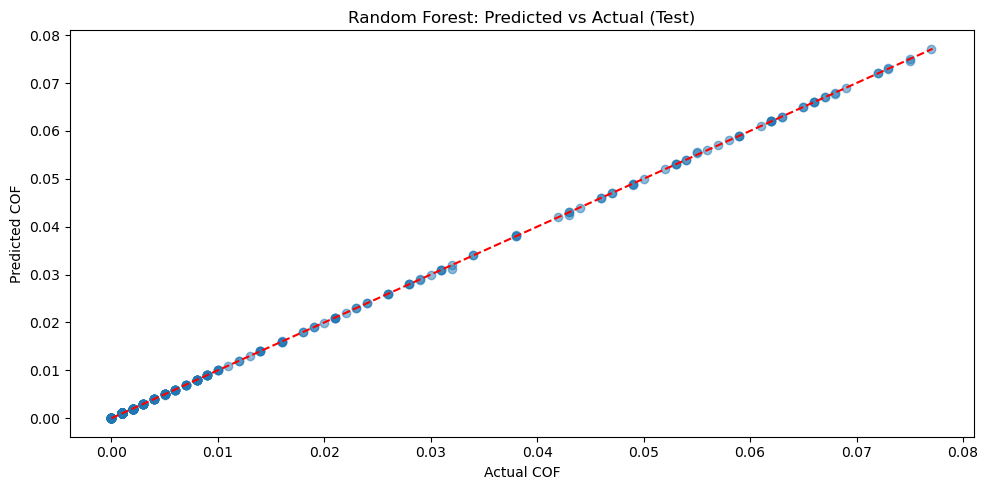

In [6]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(y_test[:500], y_pred[:500], alpha=0.5)
ax.set_xlabel("Actual COF")
ax.set_ylabel("Predicted COF")
ax.set_title("Random Forest: Predicted vs Actual (Test)")

min_val = min(y_test[:500].min(), y_pred[:500].min())
max_val = max(y_test[:500].max(), y_pred[:500].max())
ax.plot([min_val, max_val], [min_val, max_val], "r--")

fig.tight_layout()
fig.savefig("results/figures/rf_predicted_vs_actual.png", dpi=300)
plt.show()



In [36]:
print("rf exists:", "rf" in globals())
print("X exists:", "X" in globals())

import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

# Feature importance from Random Forest
feat_importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
feat_importances.plot(kind="bar", ax=ax)
ax.set_ylabel("Importance")
ax.set_title("Random Forest Feature Importance")

fig.tight_layout()
fig.savefig("results/figures/feature_importance.png", dpi=300)
plt.show()



rf exists: True
X exists: True


ValueError: Length of values (10) does not match length of index (7)

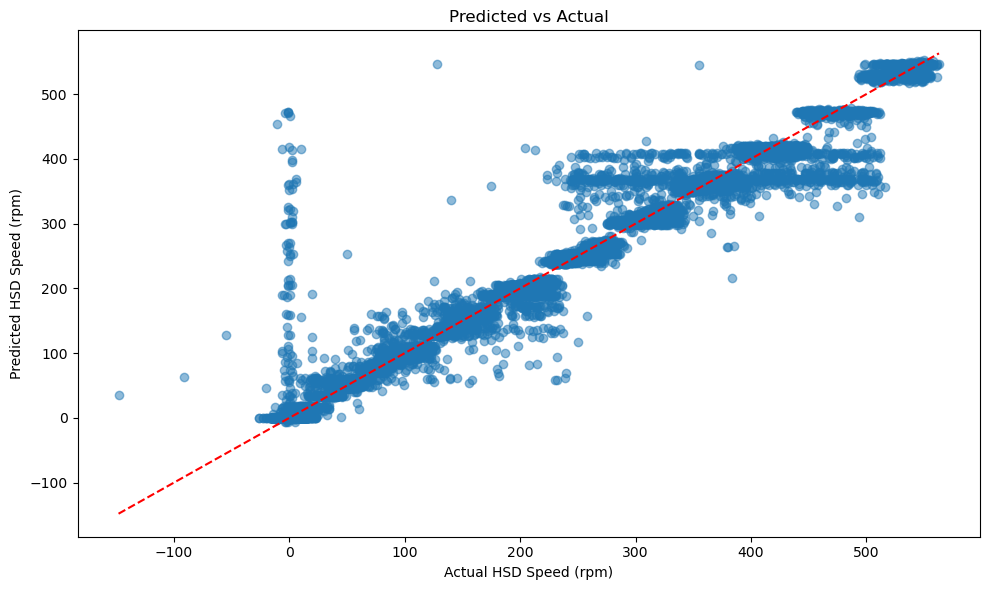

In [38]:
# Predict
y_pred = model.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual HSD Speed (rpm)")
plt.ylabel("Predicted HSD Speed (rpm)")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.tight_layout()
plt.savefig("results/figures/predicted_vs_actual.png", dpi=300)
plt.show()


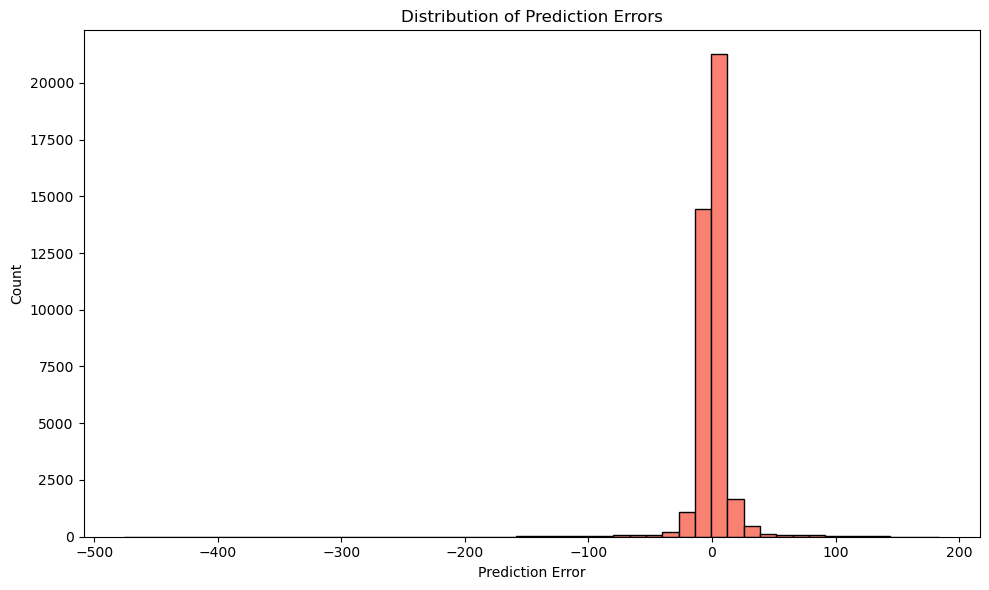

In [43]:
errors = y_test - y_pred
plt.figure(figsize=(10,6))
plt.hist(errors, bins=50, color='salmon', edgecolor='black')
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.savefig("results/figures/error_distribution.png", dpi=300)
plt.show()



In [46]:
import joblib

joblib.dump(model, "random_forest_model.pkl")


['random_forest_model.pkl']

In [50]:
import pandas as pd
import numpy as np

def compute_features(df, load_col='Load_kN', torque_col='Torque_Nm', speed_col='Specimen_Speed_rpm', ae_col='AE_RMS_V', radius=0.024):
    """
    Compute derived tribological features: COF, Power, AE Energy.
    """
    # Convert kN to N
    df['Load_N'] = df[load_col] * 1000
    
    # Coefficient of Friction
    df['COF'] = df[torque_col] / (df['Load_N'] * radius)
    
    # Frictional Power (Torque in Nm, Speed in rpm → rad/s)
    df['Power_W'] = df[torque_col] * (2 * np.pi * df[speed_col] / 60)
    
    # AE Energy
    df['AE_Energy'] = df[ae_col]**2
    
    return df


In [51]:
from sklearn.preprocessing import StandardScaler

def normalize_features(df, feature_cols):
    """
    Standardize features to zero mean and unit variance.
    """
    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])
    return df, scaler


In [52]:
from sklearn.model_selection import train_test_split

def split_data(df, target_col='HSD_Speed_rpm'):
    """
    Split dataset into train, validation, and test sets.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    return X_train, X_val, X_test, y_train, y_val, y_test


In [53]:
X_train_small = X_train.sample(20000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(5000, random_state=42)
y_test_small = y_test.loc[X_test_small.index]


In [54]:
# Create a tiny sample from the FULL dataframe (not from X_train)
df_small = df.sample(1000, random_state=42)

# Split manually into X and y
X_small = df_small.drop(columns=['HSD_Speed_rpm'])
y_small = df_small['HSD_Speed_rpm']

print("Shapes:")
print(X_small.shape, y_small.shape)

print("\nMissing values in X:")
print(X_small.isna().sum())

print("\nMissing values in y:")
print(y_small.isna().sum())

print("\nFirst 5 rows of y:")
print(y_small.head())


Shapes:
(1000, 17) (1000,)

Missing values in X:
Time                      0
This_Step                 0
Step_Time                 0
Test_Time                 0
Specimen_Radius_mm        0
Displacement_um           0
AE_RMS_V                  0
Specimen_Speed_rpm        0
Load_kN                   0
Oil_bath_Temp_°C          0
Torque_Nm                 0
Revolutions               0
Friction_Coefficient      0
Wear_um                   0
Contact_temperature_°C    0
Contact_Potential_mV      0
Druck_bar                 0
dtype: int64

Missing values in y:
0

First 5 rows of y:
141962   -3.0
886989    1.0
393910    5.0
413078   -2.0
195531   -2.0
Name: HSD_Speed_rpm, dtype: float64


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X and y must already be defined here (your full dataset)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [56]:
X_train_small = X_train[:1000]
y_train_small = y_train[:1000]
X_val_small   = X_val[:300]
y_val_small   = y_val[:300]


In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit model and calculate evaluation metrics"""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    return {
        "Model": type(model).__name__,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_results = evaluate(rf_model, X_train, y_train, X_test, y_test)
rf_results


{'Model': 'RandomForestRegressor',
 'RMSE': 20.175969881233403,
 'MAE': 7.223293366503073,
 'R2': 0.9844098805887048}

In [60]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Use small subset due to slow training on full dataset
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]
X_val_small   = X_val[:2000]
y_val_small   = y_val[:2000]

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42
)

mlp.fit(X_train_small, y_train_small)

y_pred_mlp = mlp.predict(X_val_small)

mlp_results = {
    'Model': 'MLPRegressor',
    'RMSE': np.sqrt(mean_squared_error(y_val_small, y_pred_mlp)),
    'MAE': mean_absolute_error(y_val_small, y_pred_mlp),
    'R2': r2_score(y_val_small, y_pred_mlp)
}

mlp_results


/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


{'Model': 'MLPRegressor',
 'RMSE': 64.02356081056469,
 'MAE': 31.450675033835708,
 'R2': 0.8298982920158405}

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }


In [62]:
mlp_results = evaluate_model(mlp, X_test, y_test)
mlp_results['Model'] = "MLPRegressor (tuned)"
mlp_results


{'RMSE': 63.73030552623647,
 'MAE': 32.24624119551182,
 'R2': 0.8444490739907371,
 'Model': 'MLPRegressor (tuned)'}

In [63]:
from sklearn.svm import SVR

# Try a few kernels and C values
svr_models = [
    SVR(kernel='linear', C=1.0),
    SVR(kernel='linear', C=10.0),
    SVR(kernel='rbf', C=1.0, gamma='scale'),
    SVR(kernel='rbf', C=10.0, gamma='scale')
]

svr_results = []
for svr in svr_models:
    svr.fit(X_train_small, y_train_small)
    res = evaluate_model(svr, X_val_small, y_val_small)
    res['Model'] = f"SVR ({svr.kernel}, C={svr.C})"
    svr_results.append(res)

# Show results
for r in svr_results:
    print(r)


{'RMSE': 89.15510468212302, 'MAE': 46.09686123405422, 'R2': 0.6701462289774243, 'Model': 'SVR (linear, C=1.0)'}
{'RMSE': 89.38658135157755, 'MAE': 45.99430510667549, 'R2': 0.6684311825483773, 'Model': 'SVR (linear, C=10.0)'}
{'RMSE': 87.08579256009938, 'MAE': 41.06765398743389, 'R2': 0.6852805074900256, 'Model': 'SVR (rbf, C=1.0)'}
{'RMSE': 69.02229366028669, 'MAE': 27.7501915617169, 'R2': 0.8022994856721066, 'Model': 'SVR (rbf, C=10.0)'}


In [64]:
features = ['Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)', 'Displacement (um)',
            'AE_RMS (V)', 'Friction Coefficient', 'Wear (um)']
target = 'HSD Speed (rpm)'

X = df[features]
y = df[target]

print(X.head())
print(y.head())


KeyError: "None of [Index(['Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)', 'Displacement (um)',\n       'AE_RMS (V)', 'Friction Coefficient', 'Wear (um)'],\n      dtype='object')] are in the [columns]"

In [1]:
import pandas as pd

# Try using the Python engine and skip bad lines
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    encoding='latin1',       # handles special characters like °C
    engine='python',         # more flexible parser
    on_bad_lines='skip'      # skip rows that break the format
)

print(df.head())
print(df.columns)


            Data file  Unnamed: 1  \
0  Configuration file         NaN   
1    Calibration file         NaN   
2   Test control file         NaN   
3       Operator Name         NaN   
4                Date         NaN   

                                Z3251_TE92HS_034.TSV  
0  TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_1...  
1  TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_1...  
2                               Z3251_TE92HS_034.TSF  
3                                          Strablegg  
4                                         20.06.2022  
Index(['Data file', 'Unnamed: 1', 'Z3251_TE92HS_034.TSV'], dtype='object')


In [2]:
# Peek first 50 lines to find where the actual data starts
with open('Z3251_TE92HS_034.TSV', 'r', encoding='latin1') as f:
    for i in range(50):
        print(f.readline())


Data file		Z3251_TE92HS_034.TSV

Configuration file		TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_10_FOR_ALL_PARAMETERS_CORRECTED_HIGHSPEED.CFG

Calibration file		TE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_10_FOR_ALL_PARAMETERS_CORRECTED_HIGHSPEED.CAL

Test control file		Z3251_TE92HS_034.TSF



Operator Name		 Strablegg

Date		20.06.2022

Test ID		5000 Zyklen +15sec. wait

Test Fluid		271-A; 120°C

Test Details		Z3251_TE92HS_034

		Geteilter Adapter mit Gummielementen

		

		



Test file variable V1 <Load> = .3

Test file variable V2 <Running in Speed> = 100

Test file variable V3 <Max Speed regeln> = 550

Test file variable V4 <min Speed regeln> = 0

Test file variable V5 <max speed schalten> = 500

Test file variable V6 <min speed schalten> = 10

Test file variable V7 <wait time> = 15

Test file variable V8 <Temp.Level> = 120

Test started at 13:06:43 on 20/06/2022

	Time	This Step	Step Time	Test Time	Specimen Radius (mm)	Displacement (um)	AE_RMS (V)	Specimen Speed (rpm)	Load (kN)

In [3]:
import pandas as pd

# Adjust skiprows based on where your numeric table starts
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    encoding='latin1',
    skiprows=34,  # skip all metadata lines before the table
    engine='python'
)

# Optional: rename columns to remove extra spaces
df.columns = [c.strip() for c in df.columns]

# Quick check
print(df.head())
print(df.columns)


  Unnamed: 0  13:08:03  3  600.   80.  24.30    1184  -0.0317    0  0.301  \
0        NaN  13:08:03  3  600.  80.1   24.3  1184.0  -0.0537  0.0  0.300   
1        NaN  13:08:03  3  600.  80.2   24.3  1184.0  -0.0415  0.0  0.301   
2        NaN  13:08:03  3  600.  80.3   24.3  1184.0  -0.0439  0.0  0.301   
3        NaN  13:08:03  3  600.  80.4   24.3  1184.0  -0.0537  0.0  0.301   
4        NaN  13:08:03  3  600.  80.5   24.3  1184.0  -0.0439  0.0  0.301   

     25  0.035  0.1  0.000   -1184  25.1  0.9  825.3    1  Unnamed: 19  
0  25.0  0.128  0.0  0.002 -1184.0  25.0  0.9  825.3  1.0          NaN  
1  25.0  0.289  0.0  0.004 -1184.0  25.0  0.9  825.3  3.0          NaN  
2  25.0  0.526  0.0  0.007 -1184.0  25.0  0.9  825.3 -7.0          NaN  
3  25.0  0.845  0.0  0.012 -1184.0  25.0  1.0  825.3 -4.0          NaN  
4  25.0  1.260  0.0  0.017 -1184.0  25.0  1.0  825.3 -4.0          NaN  
Index(['Unnamed: 0', '13:08:03', '3', '600.', '80.', '24.30', '1184',
       '-0.0317', '0', '0.301

In [4]:
import pandas as pd

df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    encoding='latin1',
    skiprows=34,  # adjust if needed
    engine='python'
)
df.columns = [c.strip() for c in df.columns]  # clean column names



In [5]:
print(df.columns.tolist())


['Unnamed: 0', '13:08:03', '3', '600.', '80.', '24.30', '1184', '-0.0317', '0', '0.301', '25', '0.035', '0.1', '0.000', '-1184', '25.1', '0.9', '825.3', '1', 'Unnamed: 19']


In [6]:
import pandas as pd

# Try reading with latin1 encoding
df = pd.read_csv('Z3251_TE92HS_034.TSV', sep='\t', skiprows=30, encoding='latin1')

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Quick check
print(df.head())
print(df.columns.tolist())


  Unnamed: 0  13:08:02  3  600.  79.6  24.30    1184  -0.0537    0  0.300  \
0        NaN  13:08:02  3  600.  79.7   24.3  1184.0  -0.0415  0.0  0.300   
1        NaN  13:08:03  3  600.  79.8   24.3  1184.0  -0.0463  0.0  0.300   
2        NaN  13:08:03  3  600.  79.9   24.3  1184.0  -0.0415  0.0  0.301   
3        NaN  13:08:03  3  600.  80.0   24.3  1184.0  -0.0317  0.0  0.301   
4        NaN  13:08:03  3  600.  80.1   24.3  1184.0  -0.0537  0.0  0.300   

     25  -0.008  0.1  0.000   -1184  25.1  0.8  825.3     6  Unnamed: 19  
0  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.8  825.3   4.0          NaN  
1  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  12.0          NaN  
2  25.0  -0.008  0.0  0.000 -1184.0  25.0  0.9  825.3  10.0          NaN  
3  25.0   0.035  0.0  0.000 -1184.0  25.0  0.9  825.3   1.0          NaN  
4  25.0   0.128  0.0  0.002 -1184.0  25.0  0.9  825.3   1.0          NaN  
['Unnamed: 0', '13:08:02', '3', '600.', '79.6', '24.30', '1184', '-0.0537', '0', '0.300

In [7]:
import pandas as pd

# Column names based on your TSV
columns = [
    'Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
    'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
    'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions', 'Friction Coefficient',
    'Wear (um)', 'Contact temperature (°C)', 'Contact Potential (mV)', 'Druck (bar)',
    'HSD Speed (rpm)'
]

# Load TSV, skipping metadata rows and using your defined columns
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    skiprows=33,  # adjust depending on how many metadata rows before the table
    names=columns,
    encoding='latin1'
)

# Quick check
print(df.head())
print(df.columns.tolist())


             Time This Step  Step Time  Test Time  Specimen Radius (mm)  \
NaN 13:08:03    3      600.       79.9       24.3                1184.0   
    13:08:03    3      600.       80.0       24.3                1184.0   
    13:08:03    3      600.       80.1       24.3                1184.0   
    13:08:03    3      600.       80.2       24.3                1184.0   
    13:08:03    3      600.       80.3       24.3                1184.0   

              Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
NaN 13:08:03            -0.0415         0.0                 0.301       25.0   
    13:08:03            -0.0317         0.0                 0.301       25.0   
    13:08:03            -0.0537         0.0                 0.300       25.0   
    13:08:03            -0.0415         0.0                 0.301       25.0   
    13:08:03            -0.0439         0.0                 0.301       25.0   

              Oil bath Temp (°C)  Torque (Nm)  Revolutions  \
NaN 13

In [8]:
import pandas as pd

# Define proper column names
columns = [
    'Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
    'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
    'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions', 'Friction Coefficient',
    'Wear (um)', 'Contact temperature (°C)', 'Contact Potential (mV)', 'Druck (bar)',
    'HSD Speed (rpm)'
]

# Load TSV, skip metadata, specify columns and encoding
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    skiprows=33,       # start from the actual numeric table
    names=columns,
    usecols=columns,   # ensure only the correct columns
    encoding='latin1'
)

# Drop any rows that have NaN values
df = df.dropna()

print(df.shape)
print(df.head())


(0, 18)
Empty DataFrame
Columns: [Time, This Step, Step Time, Test Time, Specimen Radius (mm), Displacement (um), AE_RMS (V), Specimen Speed (rpm), Load (kN), Oil bath Temp (°C), Torque (Nm), Revolutions, Friction Coefficient, Wear (um), Contact temperature (°C), Contact Potential (mV), Druck (bar), HSD Speed (rpm)]
Index: []


In [9]:
import pandas as pd

# Skip metadata rows and load only the real table
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    skiprows=33,       # skip header/metadata
    names=columns,
    usecols=columns,   # ensure only the numeric columns
    encoding='latin1'  # handle special characters like °C
)

# Drop any rows that are incomplete
df = df.dropna()


In [10]:
features = [
    'Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)',
    'Displacement (um)', 'AE_RMS (V)', 'Friction Coefficient', 'Wear (um)'
]
target = 'HSD Speed (rpm)'

X = df[features]
y = df[target]


In [11]:
df = pd.read_csv(
    'Z3251_TE92HS_034.TSV',
    sep='\t',
    skiprows=33,      # adjust if needed
    encoding='latin1'
)

print(df.head())
print(df.shape)


  Unnamed: 0  13:08:03  3  600.  79.9  24.30    1184  -0.0415    0  0.301  \
0        NaN  13:08:03  3  600.  80.0   24.3  1184.0  -0.0317  0.0  0.301   
1        NaN  13:08:03  3  600.  80.1   24.3  1184.0  -0.0537  0.0  0.300   
2        NaN  13:08:03  3  600.  80.2   24.3  1184.0  -0.0415  0.0  0.301   
3        NaN  13:08:03  3  600.  80.3   24.3  1184.0  -0.0439  0.0  0.301   
4        NaN  13:08:03  3  600.  80.4   24.3  1184.0  -0.0537  0.0  0.301   

     25  -0.008  0.1  0.000   -1184  25.1  0.9  825.3   10  Unnamed: 19  
0  25.0   0.035  0.0  0.000 -1184.0  25.0  0.9  825.3  1.0          NaN  
1  25.0   0.128  0.0  0.002 -1184.0  25.0  0.9  825.3  1.0          NaN  
2  25.0   0.289  0.0  0.004 -1184.0  25.0  0.9  825.3  3.0          NaN  
3  25.0   0.526  0.0  0.007 -1184.0  25.0  0.9  825.3 -7.0          NaN  
4  25.0   0.845  0.0  0.012 -1184.0  25.0  1.0  825.3 -4.0          NaN  
(1131410, 20)


In [12]:
print(df.columns.tolist())


['Unnamed: 0', '13:08:03', '3', '600.', '79.9', '24.30', '1184', '-0.0415', '0', '0.301', '25', '-0.008', '0.1', '0.000', '-1184', '25.1', '0.9', '825.3', '10', 'Unnamed: 19']


In [13]:
df = df.dropna(how='all')


In [14]:
import pandas as pd

# define the correct column names
cols = [
    'Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
    'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
    'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions', 'Friction Coefficient',
    'Wear (um)', 'Contact temperature (°C)', 'Contact Potential (mV)',
    'Druck (bar)', 'HSD Speed (rpm)'
]

# load TSV, skipping metadata rows at the top
df = pd.read_csv('Z3251_TE92HS_034.TSV', sep='\t', skiprows=30, names=cols, encoding='latin1')

# verify
print(df.head())
print(df.columns.tolist())


             Time This Step  Step Time  Test Time  Specimen Radius (mm)  \
NaN 13:08:02    3      600.       79.6       24.3                1184.0   
    13:08:02    3      600.       79.7       24.3                1184.0   
    13:08:03    3      600.       79.8       24.3                1184.0   
    13:08:03    3      600.       79.9       24.3                1184.0   
    13:08:03    3      600.       80.0       24.3                1184.0   

              Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
NaN 13:08:02            -0.0537         0.0                 0.300       25.0   
    13:08:02            -0.0415         0.0                 0.300       25.0   
    13:08:03            -0.0463         0.0                 0.300       25.0   
    13:08:03            -0.0415         0.0                 0.301       25.0   
    13:08:03            -0.0317         0.0                 0.301       25.0   

              Oil bath Temp (°C)  Torque (Nm)  Revolutions  \
NaN 13

In [15]:
features = [
    'Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)',
    'Displacement (um)', 'AE_RMS (V)', 'Friction Coefficient', 'Wear (um)'
]

target = 'HSD Speed (rpm)'

X = df[features]
y = df[target]


In [16]:
features = [
    'Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)',
    'Displacement (um)', 'AE_RMS (V)', 'Friction Coefficient', 'Wear (um)'
]

target = 'HSD Speed (rpm)'

X = df[features]
y = df[target]


In [17]:
print(X.isna().sum())
print(y.isna().sum())


Specimen Speed (rpm)    52
Load (kN)               52
Torque (Nm)             52
Displacement (um)       52
AE_RMS (V)              52
Friction Coefficient    52
Wear (um)               52
dtype: int64
1131414


In [18]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [21]:

X_filled = X.fillna(X.mean())
y_filled = y.fillna(y.mean())


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_filled, test_size=0.2, random_state=42)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_filled, test_size=0.2, random_state=42)


In [23]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Define the kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# Initialize the GPR
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, random_state=42)


In [24]:
y_filled = y.fillna(y.mean())  # or y.median()


In [25]:
y_clean = y_clean.values.ravel()
# or if you filled NaNs:
y_filled = y_filled.values.ravel()


NameError: name 'y_clean' is not defined

In [26]:
print(X_clean.head())        # if X_clean is still a DataFrame
print(y_clean[:5])           # first 5 elements of the NumPy array
print(X_clean.shape, y_clean.shape)


NameError: name 'X_clean' is not defined

In [27]:
print(df.isna().sum())


Time                              1
This Step                        52
Step Time                        52
Test Time                        52
Specimen Radius (mm)             52
Displacement (um)                52
AE_RMS (V)                       52
Specimen Speed (rpm)             52
Load (kN)                        52
Oil bath Temp (°C)               52
Torque (Nm)                      52
Revolutions                      52
Friction Coefficient             52
Wear (um)                        52
Contact temperature (°C)         52
Contact Potential (mV)           52
Druck (bar)                      52
HSD Speed (rpm)             1131414
dtype: int64


In [28]:
import os
print(os.getcwd())


/home/jovyan/work/Mywork


In [29]:
with open('/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV', 'rb') as f:
    raw = f.read(500)

raw[:200]


b'Data file\t\tZ3251_TE92HS_034.TSV\r\nConfiguration file\t\tTE92 2KN_JOURNALBEARING_2019_10_17_SMOOTHING_10_FOR_ALL_PARAMETERS_CORRECTED_HIGHSPEED.CFG\r\nCalibration file\t\tTE92 2KN_JOURNALBEARING_2019_10_17_SM'

In [30]:
import pandas as pd

path = "/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV"

df = pd.read_csv(
    path,
    sep="\t",
    skiprows=23,        
    encoding="latin1",  
    engine="python"
)

print(df.shape)
print(df.columns)
df.head()

(1131420, 20)
Index(['Unnamed: 0', 'Time', 'This Step', 'Step Time', 'Test Time',
       'Specimen Radius (mm)', 'Displacement (um)', 'AE_RMS (V)',
       'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)',
       'Torque (Nm)', 'Revolutions', 'Friction Coefficient', 'Wear (um)',
       'Contact temperature (°C)', 'Contact Potential (mV)', 'Druck (bar)',
       'HSD Speed (rpm)', 'Unnamed: 19'],
      dtype='object')


,Unnamed: 0,Time,This Step,Step Time,Test Time,Specimen Radius (mm),Displacement (um),AE_RMS (V),Specimen Speed (rpm),Load (kN),Oil bath Temp (°C),Torque (Nm),Revolutions,Friction Coefficient,Wear (um),Contact temperature (°C),Contact Potential (mV),Druck (bar),HSD Speed (rpm),Unnamed: 19
0,NaN,13:08:02,3,600.,79.0,24.3,1184.0,-0.0537,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,1.0,NaN
1,NaN,13:08:02,3,600.,79.1,24.3,1184.0,-0.0439,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,4.0,NaN
2,NaN,13:08:02,3,600.,79.2,24.3,1184.0,-0.0659,0.0,0.3,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,2.0,NaN
3,NaN,13:08:02,3,600.,79.3,24.3,1184.0,-0.0512,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,5.0,NaN
4,NaN,13:08:02,3,600.,79.4,24.3,1184.0,-0.0512,0.0,0.3,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,-2.0,NaN


In [30]:
import pandas as pd

path = "/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV"

df = pd.read_csv(
    path,
    sep="\t",
    skiprows=23,        
    encoding="latin1",  
    engine="python"
)

print(df.shape)
print(df.columns)
df.head()

(1131420, 20)
Index(['Unnamed: 0', 'Time', 'This Step', 'Step Time', 'Test Time',
       'Specimen Radius (mm)', 'Displacement (um)', 'AE_RMS (V)',
       'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)',
       'Torque (Nm)', 'Revolutions', 'Friction Coefficient', 'Wear (um)',
       'Contact temperature (°C)', 'Contact Potential (mV)', 'Druck (bar)',
       'HSD Speed (rpm)', 'Unnamed: 19'],
      dtype='object')


,Unnamed: 0,Time,This Step,Step Time,Test Time,Specimen Radius (mm),Displacement (um),AE_RMS (V),Specimen Speed (rpm),Load (kN),Oil bath Temp (°C),Torque (Nm),Revolutions,Friction Coefficient,Wear (um),Contact temperature (°C),Contact Potential (mV),Druck (bar),HSD Speed (rpm),Unnamed: 19
0,NaN,13:08:02,3,600.,79.0,24.3,1184.0,-0.0537,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,1.0,NaN
1,NaN,13:08:02,3,600.,79.1,24.3,1184.0,-0.0439,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,4.0,NaN
2,NaN,13:08:02,3,600.,79.2,24.3,1184.0,-0.0659,0.0,0.3,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,2.0,NaN
3,NaN,13:08:02,3,600.,79.3,24.3,1184.0,-0.0512,0.0,0.3,25.0,-0.004,0.0,0.0,-1184.0,25.0,0.8,825.3,5.0,NaN
4,NaN,13:08:02,3,600.,79.4,24.3,1184.0,-0.0512,0.0,0.3,25.0,-0.008,0.0,0.0,-1184.0,25.0,0.8,825.3,-2.0,NaN


In [31]:
# Remove empty / unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(df.columns)
print(df.shape)


Index(['Time', 'This Step', 'Step Time', 'Test Time', 'Specimen Radius (mm)',
       'Displacement (um)', 'AE_RMS (V)', 'Specimen Speed (rpm)', 'Load (kN)',
       'Oil bath Temp (°C)', 'Torque (Nm)', 'Revolutions',
       'Friction Coefficient', 'Wear (um)', 'Contact temperature (°C)',
       'Contact Potential (mV)', 'Druck (bar)', 'HSD Speed (rpm)'],
      dtype='object')
(1131420, 18)


In [32]:
df.isna().sum()


Time                        52
This Step                    1
Step Time                   52
Test Time                   52
Specimen Radius (mm)        52
Displacement (um)           52
AE_RMS (V)                  52
Specimen Speed (rpm)        52
Load (kN)                   52
Oil bath Temp (°C)          52
Torque (Nm)                 52
Revolutions                 52
Friction Coefficient        52
Wear (um)                   52
Contact temperature (°C)    52
Contact Potential (mV)      52
Druck (bar)                 52
HSD Speed (rpm)             52
dtype: int64

In [33]:
features = [
    'Specimen Speed (rpm)',
    'Load (kN)',
    'Torque (Nm)',
    'Displacement (um)',
    'AE_RMS (V)',
    'Friction Coefficient'
]

X = df[features]
y = df['Wear (um)']

print(X.shape, y.shape)


(1131420, 6) (1131420,)


In [34]:
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

print(X_clean.shape, y_clean.shape)


(1131368, 6) (1131368,)


In [35]:
print(y_clean.describe())


count    1131368.0
mean       -1184.0
std            0.0
min        -1184.0
25%        -1184.0
50%        -1184.0
75%        -1184.0
max        -1184.0
Name: Wear (um), dtype: float64


In [36]:
target = "Friction Coefficient"


In [37]:
features = [
    "Specimen Speed (rpm)",
    "Load (kN)",
    "Torque (Nm)",
    "AE_RMS (V)",
    "Oil bath Temp (°C)"
]

target = "Friction Coefficient"

df_ml = df[features + [target]].dropna()

print(df_ml.shape)
df_ml.describe()


(1131368, 6)


,Specimen Speed (rpm),Load (kN),Torque (Nm),AE_RMS (V),Oil bath Temp (°C),Friction Coefficient
count,1.131368e+06,1.131368e+06,1.131368e+06,1.131368e+06,1.131368e+06,1.131368e+06
mean,8.553078e+01,2.998762e-01,3.386006e-01,4.117184e-01,1.195216e+02,4.637670e-03
std,1.390346e+02,2.236768e-03,9.544617e-01,9.633094e-01,6.921374e+00,1.310764e-02
min,0.000000e+00,2.890000e-01,-1.600000e-02,-1.049000e-01,2.500000e+01,0.000000e+00
25%,0.000000e+00,2.990000e-01,1.000000e-03,-5.370000e-02,1.200000e+02,0.000000e+00
50%,3.000000e+00,3.000000e-01,5.000000e-03,-4.630000e-02,1.200000e+02,0.000000e+00
75%,1.250000e+02,3.020000e-01,9.400000e-02,7.800000e-02,1.200000e+02,1.000000e-03
max,5.030000e+02,3.140000e-01,7.693000e+00,5.729300e+00,1.300000e+02,1.060000e-01


In [1]:
import pandas as pd

file_path = "/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV"

# Прочитај го TSV со кодирање cp1252
df = pd.read_csv(file_path, sep="\t", skiprows=23, engine="python", encoding="cp1252")

print(df.head())
print(df.columns)


  Unnamed: 0      Time This Step Step Time  Test Time  Specimen Radius (mm)  \
0        NaN  13:08:02         3      600.       79.0                  24.3   
1        NaN  13:08:02         3      600.       79.1                  24.3   
2        NaN  13:08:02         3      600.       79.2                  24.3   
3        NaN  13:08:02         3      600.       79.3                  24.3   
4        NaN  13:08:02         3      600.       79.4                  24.3   

   Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
0             1184.0     -0.0537                   0.0        0.3   
1             1184.0     -0.0439                   0.0        0.3   
2             1184.0     -0.0659                   0.0        0.3   
3             1184.0     -0.0512                   0.0        0.3   
4             1184.0     -0.0512                   0.0        0.3   

   Oil bath Temp (°C)  Torque (Nm)  Revolutions  Friction Coefficient  \
0                25.0       -0.004   

In [2]:
print(df.columns)


Index(['Unnamed: 0', 'Time', 'This Step', 'Step Time', 'Test Time',
       'Specimen Radius (mm)', 'Displacement (um)', 'AE_RMS (V)',
       'Specimen Speed (rpm)', 'Load (kN)', 'Oil bath Temp (°C)',
       'Torque (Nm)', 'Revolutions', 'Friction Coefficient', 'Wear (um)',
       'Contact temperature (°C)', 'Contact Potential (mV)', 'Druck (bar)',
       'HSD Speed (rpm)', 'Unnamed: 19'],
      dtype='object')


In [3]:
# num of col
num_cols = ['Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)', 
            'AE_RMS (V)', 'Oil bath Temp (°C)', 'Friction Coefficient', 
            'Wear (um)']

# float
df[num_cols] = df[num_cols].astype(float)

#check NaN
print(df[num_cols].isna().sum())

# statistics
print(df[num_cols].describe())


Specimen Speed (rpm)    52
Load (kN)               52
Torque (Nm)             52
AE_RMS (V)              52
Oil bath Temp (°C)      52
Friction Coefficient    52
Wear (um)               52
dtype: int64
       Specimen Speed (rpm)     Load (kN)   Torque (Nm)    AE_RMS (V)  \
count          1.131368e+06  1.131368e+06  1.131368e+06  1.131368e+06   
mean           8.553078e+01  2.998762e-01  3.386006e-01  4.117184e-01   
std            1.390346e+02  2.236768e-03  9.544617e-01  9.633094e-01   
min            0.000000e+00  2.890000e-01 -1.600000e-02 -1.049000e-01   
25%            0.000000e+00  2.990000e-01  1.000000e-03 -5.370000e-02   
50%            3.000000e+00  3.000000e-01  5.000000e-03 -4.630000e-02   
75%            1.250000e+02  3.020000e-01  9.400000e-02  7.800000e-02   
max            5.030000e+02  3.140000e-01  7.693000e+00  5.729300e+00   

       Oil bath Temp (°C)  Friction Coefficient  Wear (um)  
count        1.131368e+06          1.131368e+06  1131368.0  
mean         1.195

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- 1. Load TSV with proper encoding ---
file_path = "/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV"
df = pd.read_csv(file_path, sep="\t", skiprows=23, engine="python", encoding="latin1")  # latin1 избегнува UnicodeDecodeError

# --- 2. Drop irrelevant or empty columns ---
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 19'], errors='ignore')  # ignore ако не постојат
df = df.drop(columns=['Wear (um)'])  # фиксирана колона

# --- 3. Convert numeric columns ---
num_cols = ['Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)', 'AE_RMS (V)', 'Oil bath Temp (°C)', 'Friction Coefficient']
df[num_cols] = df[num_cols].astype(float)

# --- 4. Create derived tribological features ---
# Power [W] = Torque [Nm] * angular speed [rad/s] ; rpm -> rad/s
df['Angular Speed (rad/s)'] = df['Specimen Speed (rpm)'] * 2 * 3.14159265 / 60
df['Power (W)'] = df['Torque (Nm)'] * df['Angular Speed (rad/s)']

# AE energy as squared AE_RMS
df['AE_energy'] = df['AE_RMS (V)'] ** 2

# --- 5. Filter out extreme or invalid values ---
df = df[df['Specimen Speed (rpm)'] >= 0]  # example filter
df = df[df['Torque (Nm)'] >= -1]  # remove clearly invalid negative spikes
df = df[df['AE_RMS (V)'].between(-5, 5)]  # reasonable AE range

# --- 6. Normalize / standardize numeric features ---
features_to_scale = ['Specimen Speed (rpm)', 'Load (kN)', 'Torque (Nm)', 'AE_RMS (V)', 'Oil bath Temp (°C)',
                     'Friction Coefficient', 'Power (W)', 'AE_energy']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# --- 7. Check result ---
print(df_scaled.head())
print(df_scaled.describe())

       Time This Step Step Time  Test Time  Specimen Radius (mm)  \
0  13:08:02         3      600.       79.0                  24.3   
1  13:08:02         3      600.       79.1                  24.3   
2  13:08:02         3      600.       79.2                  24.3   
3  13:08:02         3      600.       79.3                  24.3   
4  13:08:02         3      600.       79.4                  24.3   

   Displacement (um)  AE_RMS (V)  Specimen Speed (rpm)  Load (kN)  \
0             1184.0   -0.483306             -0.615245   0.055331   
1             1184.0   -0.473105             -0.615245   0.055331   
2             1184.0   -0.496005             -0.615245   0.055331   
3             1184.0   -0.480704             -0.615245   0.055331   
4             1184.0   -0.480704             -0.615245   0.055331   

   Oil bath Temp (°C)  Torque (Nm)  Revolutions  Friction Coefficient  \
0          -13.654901    -0.358682          0.0              -0.35354   
1          -13.654901    -0.35

In [5]:
import numpy as np

# Assuming you have these columns already
# Torque (Nm), Load (kN), and Shaft Radius (m)
load = 0.3  # example axial load in kN, replace with your value if needed
radius = 0.024  # 24 mm radius

# Make sure Load is in N (1 kN = 1000 N)
df['COF'] = df['Torque (Nm)'] / (load * 1000 * radius)

# Optional: compute Power and AE energy
df['Power'] = df['Torque (Nm)'] * (2 * np.pi * df['Specimen Speed (rpm)'] / 60)
df['AE_Energy'] = df['AE_RMS (V)'] ** 2


In [6]:
target_col = 'COF'
X = df.drop(columns=[target_col])
y = df[target_col]


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df_small shape: (200000, 1)


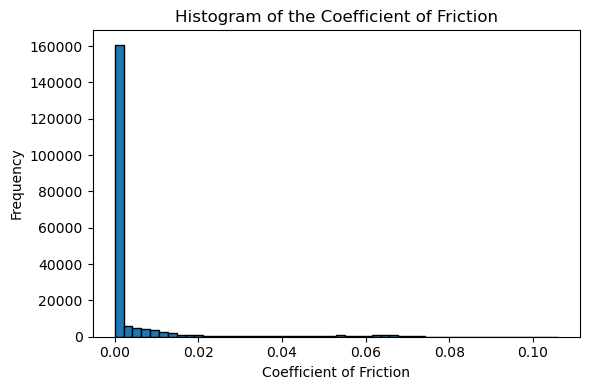

In [4]:
#  load + create df_small + plot ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load data
file_path = "/home/jovyan/work/Mywork/Z3251_TE92HS_034.TSV"

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=23,
    engine="python",
    encoding="latin1"
)

# clean columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed", na=False)]
df.columns = [c.strip() for c in df.columns]

# numeric conversion
df["Friction Coefficient"] = pd.to_numeric(df["Friction Coefficient"], errors="coerce")

# create sample
df_small = df[["Friction Coefficient"]].dropna().sample(200000, random_state=42)

print("df_small shape:", df_small.shape)

# plot histogram
plt.figure(figsize=(6,4))
plt.hist(df_small["Friction Coefficient"], bins=50, edgecolor="black")
plt.xlabel("Coefficient of Friction")
plt.ylabel("Frequency")
plt.title("Histogram of the Coefficient of Friction")
plt.tight_layout()
plt.savefig("results/figures/cof_histogram.png", dpi=300)
plt.show()



In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
os.makedirs("results/figures", exist_ok=True)
%matplotlib inline


In [42]:
targets = ["Friction Coefficient", "HSD Speed (rpm)", "Wear (um)", "AE_RMS (V)", "Contact Potential (mV)"]
for t in targets:
    if t in df.columns:
        s = pd.to_numeric(df[t], errors="coerce")
        print(t, "| n=", s.notna().sum(), "| mean=", s.mean(), "| std=", s.std())

In [5]:
import os

os.makedirs("data/processed", exist_ok=True)

df_ml.to_csv("data/processed/cleaned_data.csv", index=False)

print("Cleaned data saved to data/processed/cleaned_data.csv")


Cleaned data saved to data/processed/cleaned_data.csv
